In [1]:
import seaborn  as sns
import matplotlib.pyplot as plt 
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer # missing value imputation
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score  

In [2]:
titanic = sns.load_dataset('titanic')

features = ['pclass', 'sex', 'fare','embarked','age']
target = ['survived']

#handle missin values
imp_median = SimpleImputer(strategy='median')
titanic['age'] = imp_median.fit_transform(titanic[['age']])

imp_freq = SimpleImputer(strategy='most_frequent')
titanic['embarked'] = imp_freq.fit_transform(titanic[['embarked']]).ravel() # ravel() to convert 2D array to 1D array

# encode
le = LabelEncoder()
titanic['sex'] = le.fit_transform(titanic['sex'])
titanic['embarked'] = le.fit_transform(titanic['embarked'])

X = titanic[features]
y = titanic['survived']

# train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)




In [3]:
#model  Decision Tree Classifier

model = DecisionTreeClassifier(max_depth=5)

model.fit(X_train, y_train)

y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

print("training accuracy: ", accuracy_score(y_train, y_pred_train))
print("testing accuracy: ", accuracy_score(y_test, y_pred_test))

#classic case of overfitting

training accuracy:  0.8497191011235955
testing accuracy:  0.7988826815642458


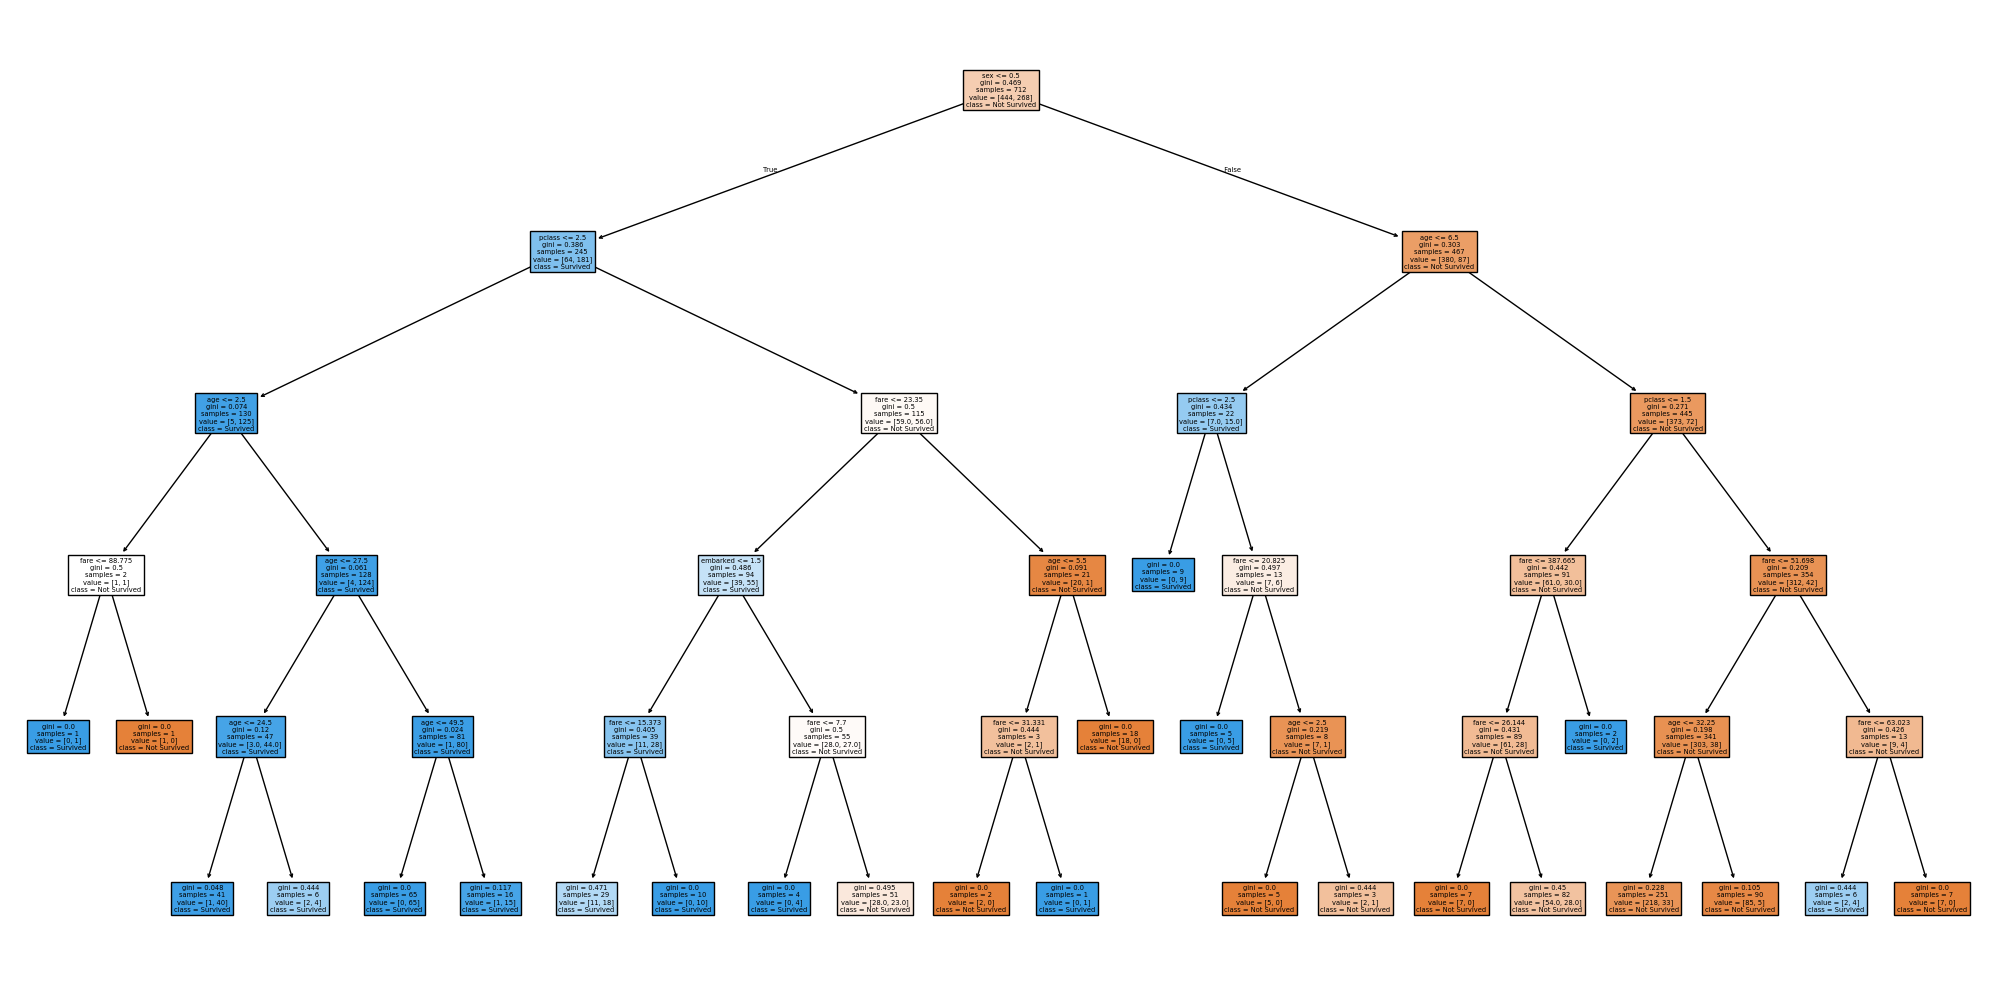

In [4]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=['Not Survived', 'Survived'],
    filled=True
)
plt.tight_layout()

In [5]:
#random forest implementation
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=151,
    oob_score=True, max_depth = 4) # use of n_estimators is to control the number of trees in the forest && obb score is to control the out of bag score

rf_model.fit(X_train, y_train) 
y_pred = rf_model.predict(X_test)

print("out of bag score: ", rf_model.oob_score_*100, "%")
print("accuracy_score: ", accuracy_score(y_test, y_pred) * 100, "%")

out of bag score:  82.86516853932584 %
accuracy_score:  81.56424581005587 %


In [ ]:
#bagging classifier
from sklearn.ensemble import BaggingClassifier

base_model = DecisionTreeClassifier()
bagging_model = BaggingClassifier(
                base_model,
                n_estimators=201)

bagging_model.fit(X_train, y_train)
y_pred = bagging_model.predict(X_test)

print("accuracy_score", accuracy_score(y_test, y_pred) * 100, "%")

accuracy_score 80.44692737430168 %


In [12]:
from sklearn.linear_model import LogisticRegression
base_model = LogisticRegression(max_iter = 2000)

bagging_model = BaggingClassifier(
                base_model,
                n_estimators=201)
bagging_model.fit(X_train, y_train)
y_pred = bagging_model.predict(X_test)

print("accuracy_score", accuracy_score(y_test, y_pred) * 100, "%")

accuracy_score 79.88826815642457 %
